# Enhanced PENet-YOLOv8n Two-Stage Training

This strictly uses the **Original PENet Paper Architecture** (~91,624 parameters) but introduces:
1. **Tone Curve (Zero-DCE style)** on the LF layer for instantaneous histogram illumination stretching.
2. **Spatial Attention Detection Gateway** before YOLO to mask out purely dark noise.
3. **Learnable Gated Fusion** in the pyramid reconstruction.

Finally, it executes a professional 2-Stage CV training loop to safely onboard YOLO to the new enhancements without destabilizing its COCO weights.

In [1]:
from penet_original import PENetWrapper
import ultralytics.nn.tasks as _t
import ultralytics.nn.modules as _m
_t.__dict__['PENetWrapper'] = PENetWrapper
_m.__dict__['PENetWrapper'] = PENetWrapper

import torch, copy
from ultralytics import YOLO

In [3]:
baseline=YOLO('yolov8m.pt')
baseline.train(
    data='exdark.yaml',
    epochs=100, imgsz=640, batch=32,
    optimizer='SGD', lr0=0.001, lrf=0.01, cos_lr=True, momentum=0.937,
    warmup_epochs=3, weight_decay=5e-4, workers=32, cache='ram', amp=True,
    patience=30, mosaic=1.0, close_mosaic=0, mixup=0.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    translate=0.1, scale=0.2, fliplr=0.5, erasing=0.2,
    project='runs/yolov8m', name='baseline', exist_ok=True, plots=True, save=True
)

New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=exdark.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline, nbs=64, nms=False,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7babc8217a10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

In [4]:



model = YOLO('pe_yolov8m.yaml')
model.model.to('cuda')


pre = YOLO('yolov8m.pt')
pre_sd = pre.model.state_dict()
mod_sd = model.model.state_dict()
shifted = {}
for k, v in pre_sd.items():
    if k.startswith('model.') and k.split('.')[1].isdigit():
        nk = 'model.' + str(int(k.split('.')[1])+1) + '.' + '.'.join(k.split('.')[2:])
        if nk in mod_sd and mod_sd[nk].shape == v.shape:
            shifted[nk] = v
model.model.load_state_dict(shifted, strict=False)
print(f'Loaded {len(shifted)} pretrained backbone weights')

enh = sum(p.numel() for p in model.model.model[0].parameters())
tot = sum(p.numel() for p in model.model.parameters())
print(f'Enhanced Author PENet Parameters: {enh:,} ({100*enh/tot:.2f}%)  Total: {tot:,}')

torch.save({
    'model': copy.deepcopy(model.model).half(),
    'train_args': {'task':'detect','data':'/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/exdark.yaml','imgsz':640,'model':'pe_yolov8n.yaml'},
}, 'penet_orig_v8m_init.pt')
print('Ready. Proceed to Stage 1.')

Loaded 469 pretrained backbone weights
Enhanced Author PENet Parameters: 121,064 (0.47%)  Total: 25,984,332
Ready. Proceed to Stage 1.


## STAGE 1: Train PENet Only (Freeze YOLO)
Forces PENet to learn to enhance ExDark images to conform exactly to what the pretrained YOLO architecture expects to see.

In [5]:
# Cell 2: Two-Stage Training (Stage 1)
from penet import PENetWrapper
import ultralytics.nn.tasks as _t
import ultralytics.nn.modules as _m
_t.__dict__['PENetWrapper'] = PENetWrapper
_m.__dict__['PENetWrapper'] = PENetWrapper

from ultralytics import YOLO
model = YOLO('penet_orig_v8m_init.pt')

yolo_layers = [i for i in range(1, 23)]


print('\n--- STARTING STAGE 1: Freezing YOLO (30 Epochs) ---')
model.info()



--- STARTING STAGE 1: Freezing YOLO (30 Epochs) ---
pe_YOLOv8m summary: 250 layers, 25,984,332 parameters, 25,984,316 gradients


(250, 25984332, 25984316, 0.0)

In [2]:
import torch
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [7]:
model.train(
    data='/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/exdark.yaml',
    epochs=30, imgsz=640, batch=32,
    optimizer='SGD', lr0=0.001, lrf=0.01, cos_lr=True, momentum=0.937,
    warmup_epochs=3, weight_decay=5e-4, workers=32, cache='ram', amp=True,
    patience=30, mosaic=1.0, close_mosaic=0, mixup=0.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    translate=0.1, scale=0.2, fliplr=0.5, erasing=0.0,
    project='runs/penet_yolov8m_ver1', name='frozen_yolo', exist_ok=True, plots=True, save=True,freeze=yolo_layers
)

New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/exdark.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22], half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=

/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30        40G      1.631       2.91      1.616        139        640: 100% ━━━━━━━━━━━━ 94/94 1.6s/it 2:281.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 2.3it/s 12.5s0.4s
                   all       1798       6204      0.727      0.599      0.672      0.409

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30        40G      1.419      1.602      1.497        185        640: 0% ──────────── 0/94  1.4s

/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30        40G      1.404      1.443      1.455        172        640: 100% ━━━━━━━━━━━━ 94/94 1.5s/it 2:221.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 2.6it/s 11.3s0.4s
                   all       1798       6204      0.776      0.708      0.774      0.502

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30        40G      1.439      1.285      1.466        208        640: 0% ──────────── 0/94  1.8s

...

/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      29/30        40G      1.184      0.948      1.317        148        640: 100% ━━━━━━━━━━━━ 94/94 1.2s/it 1:561.2sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.2it/s 9.1s0.3s
                   all       1798       6204      0.802       0.74      0.821       0.55

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/30        40G      1.191     0.9032      1.312        165        640: 0% ──────────── 0/94  1.3s

/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      30/30        40G      1.179     0.9512      1.319        124        640: 100% ━━━━━━━━━━━━ 94/94 1.2s/it 1:561.2sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.2it/s 9.1s0.3s
                   all       1798       6204      0.805      0.741       0.82       0.55

30 epochs completed in 1.100 hours.
Optimizer stripped from /home/ai21ma3ai30/aaadi/runs/detect/runs/penet_yolov8m_ver1/frozen_yolo/weights/last.pt, 52.3MB
Optimizer stripped from /home/ai21ma3ai30/aaadi/runs/detect/runs/penet_yolov8m_ver1/frozen_yolo/weights/best.pt, 52.3MB

Validating /home/ai21ma3ai30/aaadi/runs/detect/runs/penet_yolov8m_ver1/frozen_yolo/weights/best.pt...
Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
pe_YOLOv8m summary: 173 layers, 25,967,772 parameters, 0 gradients
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.0it/s 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x788b0c3e6d80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

## STAGE 2: End-to-End Fine-Tuning
Unfreezes all layers so YOLO and PENet can negotiate features globally.

In [3]:

from ultralytics import YOLO

model_stage2 = YOLO('runs/detect/runs/v8m_4.2/stage1/weights/best.pt')



print('\n--- STARTING STAGE 2: End to End Fine-Tuning (70 Epochs) ---')
model_stage2.train(
    data='/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/exdark.yaml',
    epochs=40, imgsz=640, batch=32,
    optimizer='SGD', lr0=0.0001,
    lrf=0.01, cos_lr=True, momentum=0.937,
    warmup_epochs=0, 
    weight_decay=5e-4, workers=16, cache='ram', amp=True,
    patience=30, mosaic=1.0, close_mosaic=0, mixup=0.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.5,
    translate=0.05, scale=0.3, fliplr=0.5, erasing=0.2, 
    project='runs/penet_yolov8m_ver1', name='end_to_end', exist_ok=True, plots=True, save=True,
)


--- STARTING STAGE 2: End to End Fine-Tuning (70 Epochs) ---
New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/exdark.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=3

/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/40      27.1G      1.266      1.064      1.364        104        640: 100% ━━━━━━━━━━━━ 94/94 1.4s/it 2:121.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 2.9it/s 9.9s0.4s
                   all       1798       6204      0.791      0.732      0.808      0.538

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/40      42.9G       1.21     0.9849      1.325        139        640: 100% ━━━━━━━━━━━━ 94/94 1.4s/it 2:081.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.6it/s 8.0s0.3s
                   all       1798       6204      0.804      0.739      0.818      0.549

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      39/40      42.9G      1.062     0.8003      1.223        140        640: 100% ━━━━━━━━━━━━ 94/94 1.4s/it 2:081.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.6it/s 8.2s0.3s
                   all       1798       6204      0.816      0.761      0.842      0.582

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/home/ai21ma3ai30/aaadi/yolo_env/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      40/40      42.9G      1.063     0.8027      1.226        166        640: 100% ━━━━━━━━━━━━ 94/94 1.4s/it 2:081.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.6it/s 8.0s0.3s
                   all       1798       6204      0.813      0.763      0.842      0.582

40 epochs completed in 1.520 hours.
Optimizer stripped from /home/ai21ma3ai30/aaadi/Final_Project_Files/runs/detect/runs/penet_yolov8m_ver1/end_to_end/weights/last.pt, 61.6MB
Optimizer stripped from /home/ai21ma3ai30/aaadi/Final_Project_Files/runs/detect/runs/penet_yolov8m_ver1/end_to_end/weights/best.pt, 61.6MB

Validating /home/ai21ma3ai30/aaadi/Final_Project_Files/runs/detect/runs/penet_yolov8m_ver1/end_to_end/weights/best.pt...
Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
pe_YOLOv8m summary (fused): 203 layers, 25,940,633 parameters, 0 gradients
                 Class     Images  Instances      Box(P   

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x76fc73104980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

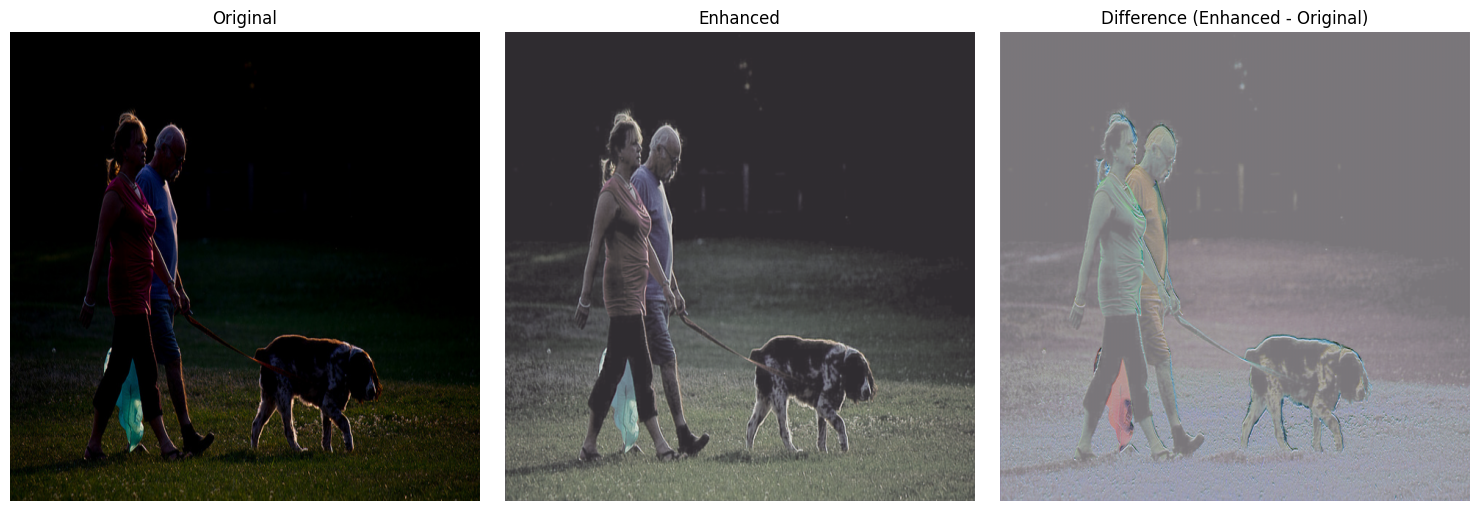

In [2]:
import torch, cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO('/home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage2/weights/best.pt')

penet_module = model.model.model[0]
penet_module.eval()
img_path = '/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_05289.jpg'

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (640, 640)) 
img_tensor = torch.from_numpy(img_resized.transpose(2, 0, 1)).float() / 255.0 
img_tensor = img_tensor.unsqueeze(0).to(model.device)

with torch.no_grad():
    enhanced_tensor = penet_module(img_tensor)
enhanced_img = enhanced_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)
enhanced_img = np.clip(enhanced_img, 0, 1) 
# -----------------------------
# Compute simple difference
# -----------------------------
orig = img_resized / 255.0
enh = enhanced_img

diff = enh - orig  # signed difference

# Normalize to visualize properly
diff_vis = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(orig)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(enh)
axes[1].set_title("Enhanced")
axes[1].axis('off')

axes[2].imshow(diff_vis)
axes[2].set_title("Difference (Enhanced - Original)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

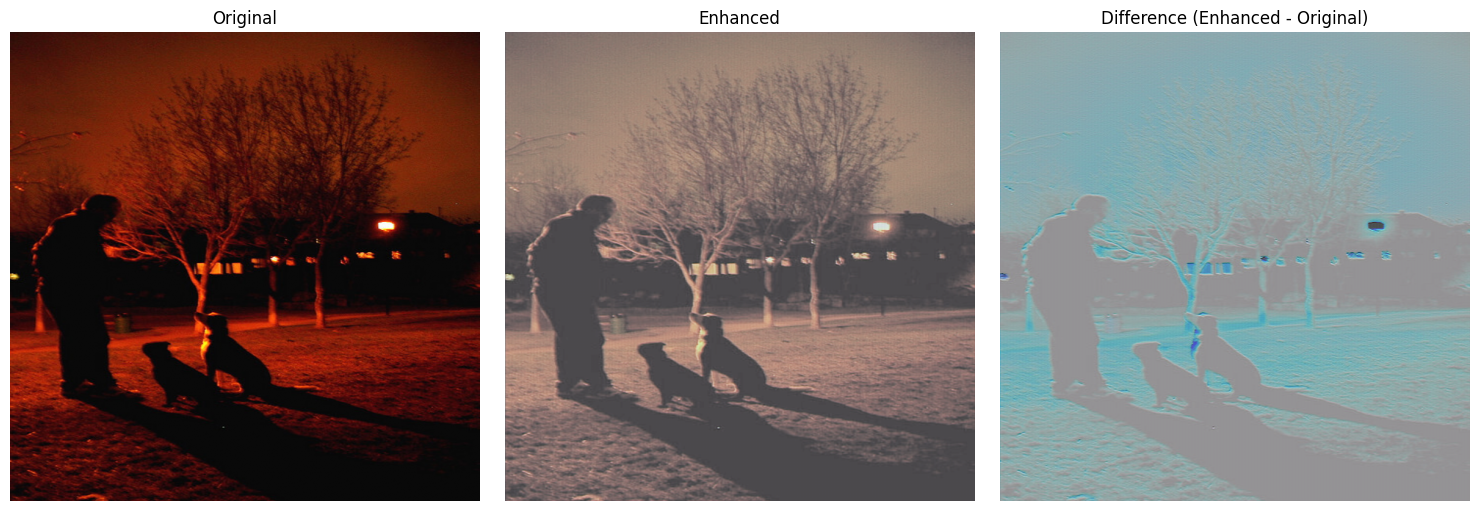

In [1]:
import torch, cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO('/home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage2/weights/best.pt')

penet_module = model.model.model[0]
penet_module.eval()
img_path = '/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/train/2015_04956.jpg'

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (640, 640)) 
img_tensor = torch.from_numpy(img_resized.transpose(2, 0, 1)).float() / 255.0 
img_tensor = img_tensor.unsqueeze(0).to(model.device)

with torch.no_grad():
    enhanced_tensor = penet_module(img_tensor)
enhanced_img = enhanced_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)
enhanced_img = np.clip(enhanced_img, 0, 1) 
# -----------------------------
# Compute simple difference
# -----------------------------
orig = img_resized / 255.0
enh = enhanced_img

diff = enh - orig  # signed difference

# Normalize to visualize properly
diff_vis = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(orig)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(enh)
axes[1].set_title("Enhanced")
axes[1].axis('off')

axes[2].imshow(diff_vis)
axes[2].set_title("Difference (Enhanced - Original)")
axes[2].axis('off')

plt.tight_layout()
plt.show()


image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_05289.jpg: 448x640 1 Dog, 2 Peoples, 105.8ms
Speed: 1.0ms preprocess, 105.8ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_05289.jpg: 448x640 1 Dog, 2 Peoples, 2.9ms
Speed: 0.7ms preprocess, 2.9ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


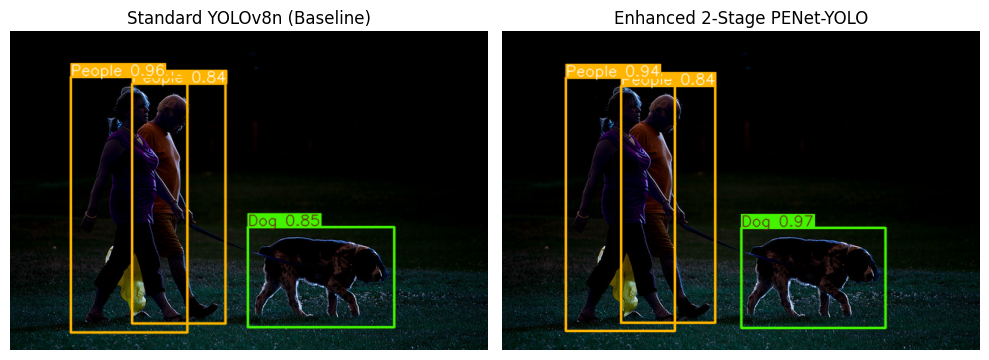

In [3]:

model = YOLO('/home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage2/weights/best.pt')
baseline=YOLO('/home/ai21ma3ai30/aaadi/runs/detect/runs/final_v8n/baseline/weights/best.pt')
results = model.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_05289.jpg', conf=0.40, agnostic_nms=True)
results2 = baseline.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_05289.jpg', conf=0.40, agnostic_nms=True)

%matplotlib inline
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(results2[0].plot())
axes[0].set_title("Standard YOLOv8n (Baseline)")
axes[0].axis('off')
axes[1].imshow(results[0].plot())
axes[1].set_title("Enhanced 2-Stage PENet-YOLO")
axes[1].axis('off')
plt.tight_layout()
plt.show()


image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/train/2015_04956.jpg: 640x480 2 Dogs, 1 People, 103.2ms
Speed: 1.0ms preprocess, 103.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/train/2015_04956.jpg: 640x480 1 person, 19.8ms
Speed: 0.8ms preprocess, 19.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)


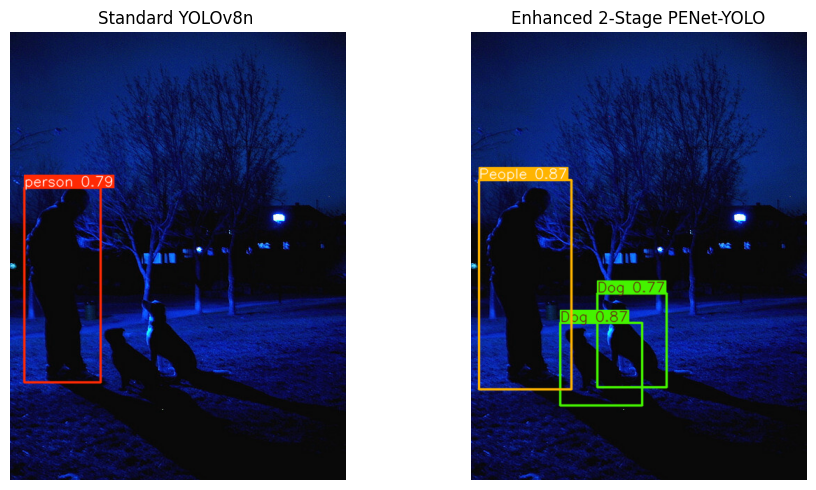

In [4]:


model = YOLO('/home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage2/weights/best.pt')
baseline=YOLO('yolov8n.pt')
results = model.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/train/2015_04956.jpg', conf=0.40, agnostic_nms=True)
results2 = baseline.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/train/2015_04956.jpg', conf=0.40, agnostic_nms=True)

%matplotlib inline
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(results2[0].plot())
axes[0].set_title("Standard YOLOv8n ")
axes[0].axis('off')
axes[1].imshow(results[0].plot())
axes[1].set_title("Enhanced 2-Stage PENet-YOLO")
axes[1].axis('off')
plt.tight_layout()
plt.show()


image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00274.jpg: 320x640 3 Bicycles, 103.9ms
Speed: 1.0ms preprocess, 103.9ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 640)

image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00274.jpg: 320x640 2 Bicycles, 3.4ms
Speed: 1.1ms preprocess, 3.4ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 640)


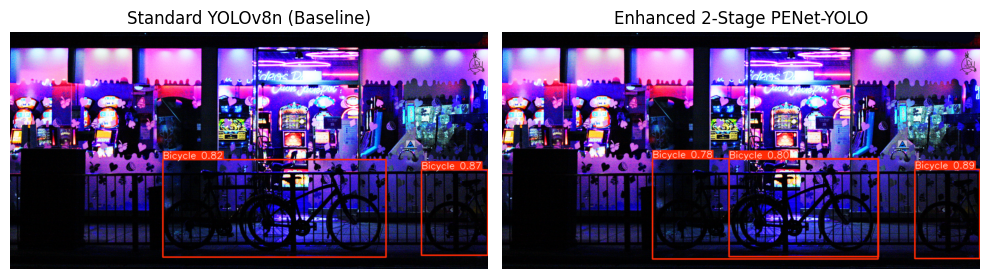

In [5]:

model = YOLO('/home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage2/weights/best.pt')
baseline=YOLO('/home/ai21ma3ai30/aaadi/runs/detect/runs/final_v8n/baseline/weights/best.pt')
results = model.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00274.jpg', conf=0.40, agnostic_nms=True)
results2 = baseline.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00274.jpg', conf=0.40, agnostic_nms=True)

%matplotlib inline
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(results2[0].plot())
axes[0].set_title("Standard YOLOv8n (Baseline)")
axes[0].axis('off')
axes[1].imshow(results[0].plot())
axes[1].set_title("Enhanced 2-Stage PENet-YOLO")
axes[1].axis('off')
plt.tight_layout()
plt.show()


image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00301.jpg: 448x640 1 Bicycle, 1 People, 11.0ms
Speed: 1.3ms preprocess, 11.0ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00301.jpg: 448x640 2 Bicycles, 1 People, 3.4ms
Speed: 1.3ms preprocess, 3.4ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


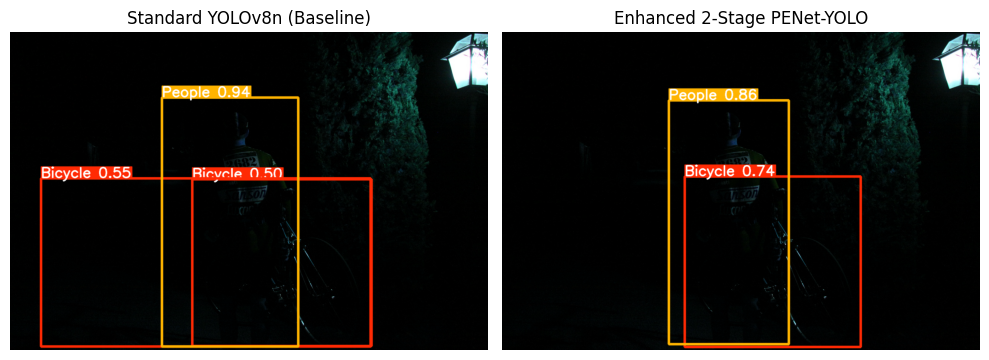

: 

In [ ]:

model = YOLO('/home/ai21ma3ai30/aaadi/version_02_04/runs/detect/runs/ver4.1/stage2/weights/best.pt')
baseline=YOLO('/home/ai21ma3ai30/aaadi/runs/detect/runs/final_v8n/baseline/weights/best.pt')
results = model.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00301.jpg', conf=0.40, agnostic_nms=True)
results2 = baseline.predict('/home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_00301.jpg', conf=0.40, agnostic_nms=True)

%matplotlib inline
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(results2[0].plot())
axes[0].set_title("Standard YOLOv8n (Baseline)")
axes[0].axis('off')
axes[1].imshow(results[0].plot())
axes[1].set_title("Enhanced 2-Stage PENet-YOLO")
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [3]:

pe_model=YOLO('/home/ai21ma3ai30/aaadi/runs/detect/runs/penet_stage_ver2/end_to_end/weights/best.pt')
baseline_fine=YOLO('/home/ai21ma3ai30/aaadi/yolov8n/baseline/weights/best.pt')
pe_model.val(data='exdark.yaml')
baseline_fine.val(data='exdark.yaml')

Ultralytics 8.4.17 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 NVL, 95319MiB)
pe_YOLOv8n summary: 153 layers, 3,129,052 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2832.9±817.8 MB/s, size: 93.9 KB)
val: Scanning /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/labels/val.cache... 1799 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 1799/1799 754.6Mit/s 0.0s
val: /home/ai21ma3ai30/aaadi/Object-Detection-and-Tracking-System/images/val/2015_05337.jpeg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.075]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 11.9it/s 9.5s0.2s
                   all       1798       6204      0.718      0.646      0.712      0.463
               Bicycle        170        237      0.753      0.781      0.807      0.519
                  Boat        152        344       0.71      0.515      0.629      0.347
      

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b4c04709790>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  